In [194]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
class CompressModel:
    def __init__(self):
        self.memory_usage_dict = None
        self.cosine_sim = None
        pass

    def read_data(self,file_path):
        return np.load(file_path) #https://stackoverflow.com/questions/38467091/numpy-reading-data-from-npy-file-directly-into-arrays
    
    def normalize_and_fit_kmeans(self,data,k):
        data_norms = np.linalg.norm(data,axis=1,keepdims=True)

        data_normalized = data/data_norms

        k_means = KMeans(k,n_init=20,random_state=26).fit(data_normalized.real)

        k_means_centroids = k_means.cluster_centers_

        k_means_labels = k_means.labels_
        k_means_labels = k_means_labels.astype(np.uint16)

        return k_means_centroids, k_means_labels,data_normalized
    
    def compute_memory_usage(self,centroids,labels,raw_data):
        original_mb = round(raw_data.nbytes / 1000000,4)

        compressed_mb = round((
            labels.nbytes +
            centroids.nbytes
        ) / 1000000,4)
        self.memory_usage_dict = {'original_data_memory_usage_mb':original_mb,'compressed_data_memory_usage_mb':compressed_mb}
        return {'original_data_memory_usage_mb':original_mb,'compressed_data_memory_usage_mb':compressed_mb}
    
    def compute_cosine_similarity(self,centroids,labels,normalize_data):
        compressed_model = centroids[labels]
        compressed_model_normalized = compressed_model / np.linalg.norm(compressed_model, axis=1, keepdims=True)

        cos_similaritys = np.sum(normalize_data*compressed_model_normalized,axis=1) # https://www.geeksforgeeks.org/python/how-to-calculate-cosine-similarity-in-python/https://www.geeksforgeeks.org/python/how-to-calculate-cosine-similarity-in-python/
        
        self.cosine_sim = np.mean(cos_similaritys)
        return np.mean(cos_similaritys)
    
        

    




In [224]:
base_model_compression = CompressModel()


In [ ]:
base_model_compression = CompressModel()

data = base_model_compression.read_data('data/AImodel.npy')

k_means_centroids, k_means_labels,data_normalized = base_model_compression.normalize_and_fit_kmeans(data,256)

memory_usage = base_model_compression.compute_memory_usage(k_means_centroids,k_means_labels,data)

cos_similarity = base_model_compression.compute_cosine_similarity(k_means_centroids,k_means_labels,data_normalized)

print(memory_usage)
print(f"Cosine Similarity: {cos_similarity}")

{'original_data_memory_usage_mb': 0.128, 'compressed_data_memory_usage_mb': 0.0348}
Cosine Similarity: 0.9252102375030518


Q 5.1 
- Normalization of data prior to clustering is important so distance calculations are not skewed by larger values. Scaling vectors to unit length  allows the algorithm to reduce the effect large values have on the distance measurement and allows for smaller values to have an equal effect. Clustering with un normalized data can lead to distance measurements between datapoints and cluster centers to be inaccurate as larger values may not be truely representative of the vectors postion to the centroids.

- Normalization of data prior to clustering is important so distance calculations are not skewed by larger values. Scaling vectors to unit length allows all features of the vector to contrubute equal to the distance measurement relative to centroids. Without normalization, relative postions of each vector to the centroid can be misrepresented as values with larger magnitudes impact the semantic intepretation of vector. 

Q 5.2
- Using a K value of 256 for K-means clustering appears to preserve the semantic similarities very well. The average cosine similarity between the original and compressed embeddings is 0.9252, indicating that the reconstructed vectors remain very close in direction to the original vectors.

- Since cosine similarity measures the angle between vectors , with 1 meaning identical direction, a value of 0.9252 shows that most of the semantic information from the original dataset is preserved after compression. This shows that the kmeans compression process effectively reduces the model size while maintaining the meaningful relationships encoded in the embeddings.

In [ ]:
test_ks= [64,128,256,512]
cos_sim_list = []
mem_usage_list = []

for k in test_ks:
    base_model_compression = CompressModel()
    data = base_model_compression.read_data('data/AImodel.npy')

    k_means_centroids, k_means_labels,data_normalized = base_model_compression.normalize_and_fit_kmeans(data,k)

    memory_usage = base_model_compression.compute_memory_usage(k_means_centroids,k_means_labels,data)
    reduction_in_memory = round((memory_usage['original_data_memory_usage_mb'] - memory_usage['compressed_data_memory_usage_mb']) / memory_usage['original_data_memory_usage_mb'],2)
    cos_similarity = base_model_compression.compute_cosine_similarity(k_means_centroids,k_means_labels,data_normalized)
    cos_sim_list.append(cos_similarity)
    mem_usage_list.append(reduction_in_memory)

mem_usage_list_percentage = [e*100 for e in mem_usage_list]



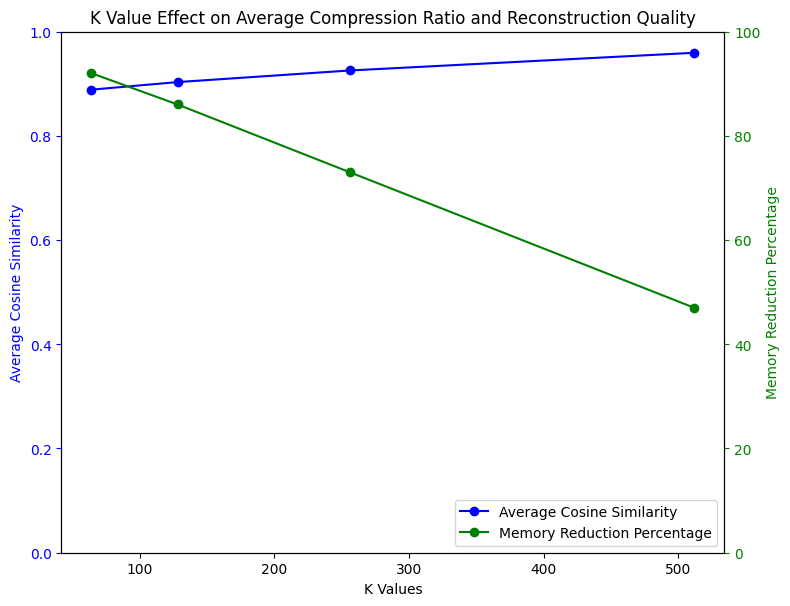

In [ ]:
#https://www.geeksforgeeks.org/data-science/draw-multiple-y-axis-scales-in-matplotlib/

fig, ax1 = plt.subplots(figsize= (8,6))
ax1.plot(test_ks,cos_sim_list,'b',label="Average Cosine Similarity",marker='o')

ax1.set_xlabel('K Values')
ax1.set_ylabel("Average Cosine Similarity",color='b')
ax1.tick_params('y',colors='b')
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()


ax2.plot(test_ks,mem_usage_list_percentage,'g',label="Memory Reduction Percentage",marker='o')

ax2.set_xlabel('K Values')
ax2.set_ylabel("Memory Reduction Percentage",color='g')
ax2.tick_params('y',colors='g')
ax2.set_ylim(0, 100)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines = lines1 + lines2 
labels = labels1 + labels2 
plt.legend(lines, labels, loc='lower right')

fig.tight_layout()
plt.title('K Value Effect on Average Compression Ratio and Reconstruction Quality')
plt.show()


5.3 
- From testing different values of K (64, 128, 256, and 512), we observe that reconstruction quality increases as K increases, while the compression ratio (memory reduction percentage) decreases. This indicates that as the number of clusters grows, the compressed model better preserves the direction of the original embeddings which improves the semantic similarities.

- Increasing K comes at the cost of larger model size and reduced memory savings.
Selection of K should be selected based on the need for semantic preservation as well as requirements based on the application of the compressed model.
